# January 2024 UK Wind Forecast Error Analysis

## Objective

This notebook analyzes BMRS January 2024 UK national wind data to answer two questions:

1. How forecast error behaves (overall, by horizon, and by time of day).
2. How much wind generation can be treated as *reliably available* for demand planning.

The app and this notebook use the same local snapshots:
- `data/actuals_wind_jan_2024.json` (FUELHH, `fuelType=WIND`)
- `data/forecasts_wind_jan_2024.json` (WINDFOR filtered to forecast horizon 0-48h)


## Assumptions and Method

- Time is treated as UTC.
- Forecast selection rule for horizon `h`: for each target time `t`, use the **latest** forecast where `publishTime <= t - h`.
- Missing forecasts are not imputed; those points are skipped for forecast-error metrics.
- Reliability of wind availability is estimated from empirical quantiles of historical actual generation (January 2024 only).

Because this is one month of data, conclusions should be interpreted as *January-conditional* rather than year-round climatology.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent

actual_path = root / 'data' / 'actuals_wind_jan_2024.json'
forecast_path = root / 'data' / 'forecasts_wind_jan_2024.json'

actuals = pd.read_json(actual_path)
forecasts = pd.read_json(forecast_path)

actuals['startTime'] = pd.to_datetime(actuals['startTime'], utc=True)
forecasts['startTime'] = pd.to_datetime(forecasts['startTime'], utc=True)
forecasts['publishTime'] = pd.to_datetime(forecasts['publishTime'], utc=True)

actuals = actuals.sort_values('startTime').reset_index(drop=True)
forecasts = forecasts.sort_values(['startTime', 'publishTime']).reset_index(drop=True)

print('Actual rows:', len(actuals))
print('Forecast rows:', len(forecasts))
print('Actual range:', actuals['startTime'].min(), 'to', actuals['startTime'].max())
print('Forecast horizon min/max (hours):', forecasts['horizonHours'].min(), forecasts['horizonHours'].max())


Actual rows: 1488
Forecast rows: 9582
Actual range: 2024-01-01 00:00:00+00:00 to 2024-01-31 23:30:00+00:00
Forecast horizon min/max (hours): 0.5 48.0


In [2]:
# Data quality checks

actual_deltas = actuals['startTime'].diff().dropna().value_counts().head()
print('Top actual startTime deltas:')
print(actual_deltas)

missing_targets = actuals[~actuals['startTime'].isin(forecasts['startTime'].unique())]
print('')
print('Targets with no forecast records:', len(missing_targets), '/', len(actuals))
print('Example missing target times:')
print(missing_targets['startTime'].head())


Top actual startTime deltas:
startTime
0 days 00:30:00    1487
Name: count, dtype: int64

Targets with no forecast records: 744 / 1488
Example missing target times:
1   2024-01-01 00:30:00+00:00
3   2024-01-01 01:30:00+00:00
5   2024-01-01 02:30:00+00:00
7   2024-01-01 03:30:00+00:00
9   2024-01-01 04:30:00+00:00
Name: startTime, dtype: datetime64[ns, UTC]


In [3]:
# Build lookup by target time for fast horizon-based selection

by_target = {
    target: group.sort_values('publishTime').reset_index(drop=True)
    for target, group in forecasts.groupby('startTime')
}

def selected_forecast_for_horizon(horizon_hours: float) -> pd.DataFrame:
    rows = []
    for _, actual in actuals.iterrows():
        target = actual['startTime']
        target_forecasts = by_target.get(target)
        if target_forecasts is None:
            continue

        cutoff = target - pd.Timedelta(hours=horizon_hours)
        valid = target_forecasts[target_forecasts['publishTime'] <= cutoff]
        if valid.empty:
            continue

        selected = valid.iloc[-1]
        error = float(selected['generation'] - actual['generation'])
        rows.append({
            'targetTime': target,
            'hour_utc': target.hour,
            'actual_mw': float(actual['generation']),
            'forecast_mw': float(selected['generation']),
            'publishTime': selected['publishTime'],
            'error_mw': error,
            'abs_error_mw': abs(error),
        })
    return pd.DataFrame(rows)


In [4]:
# Horizon error profile

horizons = np.arange(0, 48.5, 0.5)
metrics = []

for h in horizons:
    sel = selected_forecast_for_horizon(float(h))
    n = len(sel)
    metrics.append({
        'horizon_h': h,
        'n_points': n,
        'coverage_pct_of_actual_targets': 100 * n / len(actuals),
        'mae_mw': sel['abs_error_mw'].mean() if n else np.nan,
        'median_abs_error_mw': sel['abs_error_mw'].median() if n else np.nan,
        'p99_abs_error_mw': sel['abs_error_mw'].quantile(0.99) if n else np.nan,
        'bias_mw': sel['error_mw'].mean() if n else np.nan,
    })

horizon_metrics = pd.DataFrame(metrics)
horizon_metrics.head(10)


,horizon_h,n_points,coverage_pct_of_actual_targets,mae_mw,median_abs_error_mw,p99_abs_error_mw,bias_mw
0,0.00,744,50.00,"1,821.55","1,434.50","6,282.34","1,179.51"
1,0.50,744,50.00,"1,821.55","1,434.50","6,282.34","1,179.51"
2,1.00,744,50.00,"1,821.72","1,434.50","6,282.34","1,179.70"
3,1.50,744,50.00,"1,821.72","1,434.50","6,282.34","1,179.70"
4,2.00,744,50.00,"1,821.33","1,434.00","6,282.34","1,179.40"
5,2.50,744,50.00,"1,821.33","1,434.00","6,282.34","1,179.40"
6,3.00,744,50.00,"1,826.06","1,448.00","6,282.34","1,181.56"
7,3.50,744,50.00,"1,826.06","1,448.00","6,282.34","1,181.56"
8,4.00,744,50.00,"1,827.69","1,453.50","6,072.85","1,180.99"
9,4.50,744,50.00,"1,827.69","1,453.50","6,072.85","1,180.99"


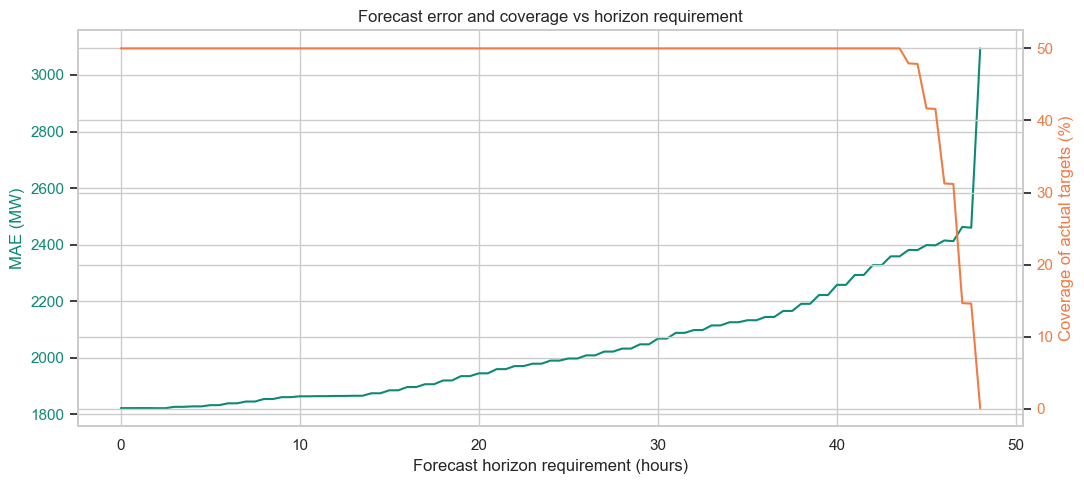

In [5]:
# Plot MAE and coverage vs forecast horizon

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(horizon_metrics['horizon_h'], horizon_metrics['mae_mw'], color='#0d8a76', label='MAE (MW)')
ax1.set_xlabel('Forecast horizon requirement (hours)')
ax1.set_ylabel('MAE (MW)', color='#0d8a76')
ax1.tick_params(axis='y', labelcolor='#0d8a76')

ax2 = ax1.twinx()
ax2.plot(horizon_metrics['horizon_h'], horizon_metrics['coverage_pct_of_actual_targets'], color='#ef7b45', label='Coverage (%)')
ax2.set_ylabel('Coverage of actual targets (%)', color='#ef7b45')
ax2.tick_params(axis='y', labelcolor='#ef7b45')

plt.title('Forecast error and coverage vs horizon requirement')
plt.tight_layout()
plt.show()


In [6]:
# Key horizon checkpoints

key_horizons = [0, 4, 8, 12, 24, 36, 47, 47.5, 48]
key_table = horizon_metrics[horizon_metrics['horizon_h'].isin(key_horizons)][[
    'horizon_h',
    'n_points',
    'coverage_pct_of_actual_targets',
    'mae_mw',
    'median_abs_error_mw',
    'p99_abs_error_mw',
    'bias_mw',
]].reset_index(drop=True)
key_table


,horizon_h,n_points,coverage_pct_of_actual_targets,mae_mw,median_abs_error_mw,p99_abs_error_mw,bias_mw
0,0.00,744,50.00,"1,821.55","1,434.50","6,282.34","1,179.51"
1,4.00,744,50.00,"1,827.69","1,453.50","6,072.85","1,180.99"
2,8.00,744,50.00,"1,853.76","1,431.50","6,320.74","1,171.40"
3,12.00,744,50.00,"1,864.60","1,435.00","6,589.70","1,176.58"
4,24.00,744,50.00,"1,989.61","1,690.50","6,724.48","1,252.46"
5,36.00,744,50.00,"2,144.00","2,011.50","7,264.33","1,305.22"
6,47.00,218,14.65,"2,462.50","2,236.50","7,301.94","1,540.02"
7,47.50,217,14.58,"2,459.75","2,235.00","7,306.12","1,533.01"
8,48.00,1,0.07,"3,094.00","3,094.00","3,094.00","3,094.00"


In [7]:
# Deep dive at 4-hour horizon (same default as app)

h4 = selected_forecast_for_horizon(4)

summary_4h = {
    'points': len(h4),
    'coverage_pct': 100 * len(h4) / len(actuals),
    'mae_mw': h4['abs_error_mw'].mean(),
    'median_abs_error_mw': h4['abs_error_mw'].median(),
    'p99_abs_error_mw': h4['abs_error_mw'].quantile(0.99),
    'bias_mw': h4['error_mw'].mean(),
}
summary_4h


{'points': 744,
 'coverage_pct': 50.0,
 'mae_mw': np.float64(1827.6922043010752),
 'median_abs_error_mw': np.float64(1453.5),
 'p99_abs_error_mw': np.float64(6072.85000000002),
 'bias_mw': np.float64(1180.9932795698924)}

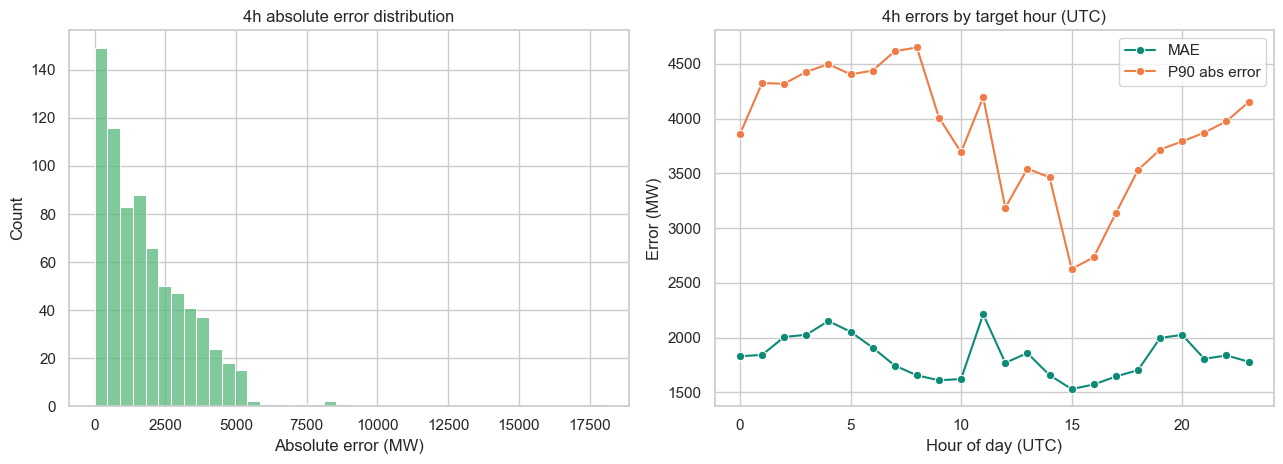

,hour_utc,mae_mw,p90_abs_error_mw,bias_mw,n
0,0,"1,830.81","3,857.00","1,418.87",31
1,1,"1,842.74","4,323.00","1,410.42",31
2,2,"2,006.39","4,317.00","1,570.90",31
3,3,"2,026.45","4,426.00","1,593.03",31
4,4,"2,152.06","4,496.00","1,606.77",31
5,5,"2,054.45","4,403.00","1,587.42",31
6,6,"1,909.71","4,437.00","1,378.03",31
7,7,"1,745.84","4,614.00","1,181.45",31
8,8,"1,656.58","4,648.00","1,122.71",31
9,9,"1,611.19","4,008.00","1,110.55",31


In [8]:
# 4-hour horizon: error distribution and time-of-day pattern

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.histplot(h4['abs_error_mw'], bins=40, ax=axes[0], color='#55b87a')
axes[0].set_title('4h absolute error distribution')
axes[0].set_xlabel('Absolute error (MW)')

hourly = h4.groupby('hour_utc').agg(
    mae_mw=('abs_error_mw', 'mean'),
    p90_abs_error_mw=('abs_error_mw', lambda s: s.quantile(0.9)),
    bias_mw=('error_mw', 'mean'),
    n=('abs_error_mw', 'size')
).reset_index()

sns.lineplot(data=hourly, x='hour_utc', y='mae_mw', marker='o', ax=axes[1], color='#0d8a76', label='MAE')
sns.lineplot(data=hourly, x='hour_utc', y='p90_abs_error_mw', marker='o', ax=axes[1], color='#ef7b45', label='P90 abs error')
axes[1].set_title('4h errors by target hour (UTC)')
axes[1].set_xlabel('Hour of day (UTC)')
axes[1].set_ylabel('Error (MW)')
axes[1].legend()

plt.tight_layout()
plt.show()

hourly


In [9]:
# Error vs generation level (4-hour horizon)

h4['generation_quartile'] = pd.qcut(h4['actual_mw'], 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
quartile_stats = h4.groupby('generation_quartile', observed=False).agg(
    mae_mw=('abs_error_mw', 'mean'),
    p90_abs_error_mw=('abs_error_mw', lambda s: s.quantile(0.9)),
    bias_mw=('error_mw', 'mean'),
    n=('abs_error_mw', 'size')
)
quartile_stats


,mae_mw,p90_abs_error_mw,bias_mw,n
generation_quartile,,,,
Q1 low,956.05,"2,077.50",560.96,186
Q2,"1,251.55","2,747.50",400.05,186
Q3,"2,245.01","4,458.50","1,041.47",186
Q4 high,"2,858.16","4,467.00","2,721.49",186


In [10]:
# Reliability analysis based on actual generation only

actual_q = actuals['generation'].quantile([0.01, 0.05, 0.10, 0.20, 0.50, 0.80, 0.90, 0.95, 0.99])
actual_q


0.01    3,233.58
0.05    4,301.10
0.10    5,087.90
0.20    6,248.80
0.50    9,863.50
0.80   13,840.40
0.90   14,809.60
0.95   15,424.65
0.99   16,130.04
Name: generation, dtype: float64

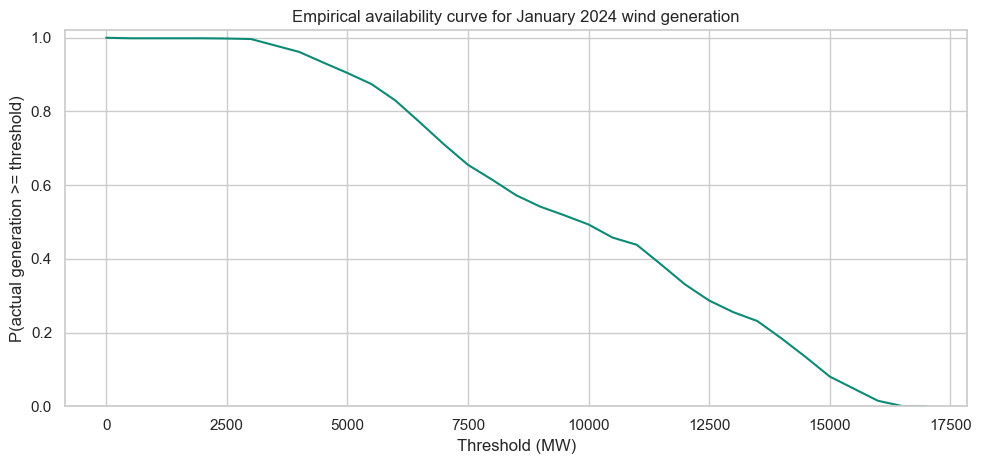

,reliability_target,recommended_mw
0,0.90,"5,087.90"
1,0.95,"4,301.10"
2,0.99,"3,233.58"


In [11]:
# Availability threshold curve: P(actual >= X)

thresholds = np.arange(0, actuals['generation'].max() + 500, 500)
availability_curve = pd.DataFrame({
    'threshold_mw': thresholds,
    'prob_actual_ge_threshold': [
        (actuals['generation'] >= x).mean() for x in thresholds
    ]
})

plt.figure(figsize=(10, 4.8))
plt.plot(availability_curve['threshold_mw'], availability_curve['prob_actual_ge_threshold'], color='#0d8a76')
plt.title('Empirical availability curve for January 2024 wind generation')
plt.xlabel('Threshold (MW)')
plt.ylabel('P(actual generation >= threshold)')
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

reliability_levels = [0.90, 0.95, 0.99]
reliable_table = pd.DataFrame({
    'reliability_target': reliability_levels,
    'recommended_mw': [actuals['generation'].quantile(1 - r) for r in reliability_levels]
})
reliable_table


## Recommendation (January 2024 evidence)

### 1) Forecast model error characteristics

- Coverage is ~50% of actual 30-minute targets because WINDFOR targets are hourly while actuals are half-hourly.
- For horizons up to about 36h (with stable sample size), MAE gradually worsens as horizon increases.
- At 4h horizon, errors are materially right-skewed (large tail events), with p99 much larger than median.
- Bias is positive (forecast > actual on average), especially in high-generation quartiles.

### 2) Reliable wind MW for planning demand

Using empirical quantiles of actual January generation:

- 90% reliability corresponds to roughly **5.1 GW**.
- 95% reliability corresponds to roughly **4.3 GW**.
- 99% reliability corresponds to roughly **3.2 GW**.

**Suggested planning value:**

Use **~5.0 GW** as a practical "reliably available" wind contribution for normal winter scheduling (about 90% reliability), and pair it with balancing reserves for low-wind intervals.

If the operational context is stricter (near-firm reliability), reduce the credited value toward **4.3 GW**.

### 3) Caveats

- This notebook uses January 2024 only; seasonality is not represented.
- Recommendation should be recalibrated with a multi-year sample before policy or contracting decisions.
